### 2026. 07. 28.  분석데이터 전처리  by 홍은경

### 1. 데이터 불러오기 및 결측치 처리

In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

raw = pd.read_csv('prj_data.csv')
raw.head()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,메모,이탈여부
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,재구매 유도 대상,1
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,재구매 유도 대상,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,NaN,0
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,재구매 유도 대상,0
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,NaN,0


In [211]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   고객ID     500 non-null    str    
 1   나이       460 non-null    float64
 2   성별       485 non-null    str    
 3   거주지역     500 non-null    str    
 4   가입경로     480 non-null    str    
 5   멤버십등급    500 non-null    str    
 6   월평균구매금액  500 non-null    float64
 7   구매횟수     500 non-null    float64
 8   리뷰점수     475 non-null    float64
 9   쿠폰사용여부   500 non-null    str    
 10  메모       216 non-null    str    
 11  이탈여부     500 non-null    int64  
dtypes: float64(4), int64(1), str(7)
memory usage: 47.0 KB


In [212]:
raw.isnull()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,메모,이탈여부
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False,False,False,True,False
496,False,False,False,False,False,False,False,False,False,False,True,False
497,False,False,False,False,False,False,False,False,False,False,True,False
498,False,False,False,False,False,False,False,False,False,False,False,False


In [213]:
raw.sum()

고객ID       C0001C0002C0003C0004C0005C0006C0007C0008C0009C...
나이                                                   19870.0
성별         남여여여남남여남남남여여여여여남여남남여남남여남남여남여여여남남남여남남남여남여남남남여남남...
거주지역       대구부산기타경기경기부산경기부산경기서울서울부산서울서울경기서울경기대구서울부산부산경기서울...
가입경로       앱웹앱앱웹앱광고앱지인추천웹웹웹웹광고앱앱웹지인추천웹광고지인추천광고웹웹앱광고앱지인추천웹...
멤버십등급      실버VIP브론즈실버골드실버골드실버브론즈골드브론즈브론즈실버골드골드브론즈브론즈VIP브론...
월평균구매금액                                      48842001.706512
구매횟수                                                  3911.0
리뷰점수                                                  1774.9
쿠폰사용여부     NYYNNNYYNNNYNNNYNYNNNNNNNNYNNNNNYNYYNYNNYNYNNN...
메모         재구매 유도 대상재구매 유도 대상재구매 유도 대상VIP 응대 필요불만 접수 이력재구...
이탈여부                                                     190
dtype: object

### - 결측치가 존재하는 컬럼 중 수치형 변수는 평균 또는 중앙값으로, 범주형 변수는 최빈값으로 대체하시오. (단, 결측 비율이 50%를 초과하는 컬럼은 삭제)

In [214]:
# 컬럼별 결측치가 차지하는  비율의 확인하기
missing_ratio = raw.isnull().mean()
missing_ratio

고객ID       0.000
나이         0.080
성별         0.030
거주지역       0.000
가입경로       0.040
멤버십등급      0.000
월평균구매금액    0.000
구매횟수       0.000
리뷰점수       0.050
쿠폰사용여부     0.000
메모         0.568
이탈여부       0.000
dtype: float64

- 결측 비율이 50% 초과하는 컬럼 삭제하기

In [215]:
# 결측 비율이 50% 초과하는 컬럼 확인하기
missing_ratio[missing_ratio > 0.5]

메모    0.568
dtype: float64

In [216]:
# 결측 비율이 50% 초과하는 컬럼 이름들 가져오기
drop_cols = missing_ratio[missing_ratio > 0.5].index

# 해당 컬럼들 삭제하기 (axis=1: 컬럼 삭제)
df = raw.drop(columns=drop_cols)
df.head()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,이탈여부
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,1
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,0
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,0
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,0


- 결측치가 존재하는 컬럼 중 수치형 변수는 중앙값으로 대체

In [217]:
#  데이터 타입이 'number'(수치형)인 컬럼만 num_cols_na 객체에 모으기
num_cols_na =df.select_dtypes(include='number').columns 

# num_cols_na에서 null이 존재하는 컬럼을 num_cols_na에 덮어쓰기
# any() : 자료형은 중요하지 않음. int, float 상관없이 모두 다
num_cols_na = num_cols_na[df[num_cols_na].isnull().any()]

num_cols_na

Index(['나이', '리뷰점수'], dtype='str')

In [218]:
# 수치형 컬럼의 결측치를 중앙값으로 채우기 
for c in num_cols_na:
    df[c] = df[c].fillna(df[c].median())
    
df.isnull().sum() 

고객ID        0
나이          0
성별         15
거주지역        0
가입경로       20
멤버십등급       0
월평균구매금액     0
구매횟수        0
리뷰점수        0
쿠폰사용여부      0
이탈여부        0
dtype: int64

- 결측치가 존재하는 컬럼 중 범주형 변수는 최빈값으로 대체

In [219]:
#  데이터 타입이 범주형인 컬럼만 cat_cols_na 객체에 모으기
cat_cols_na = df.select_dtypes(exclude='number').columns

# cat_cols_na에서 null이 존재하는 컬럼을 cat_cols_na에 덮어쓰기
cat_cols_na = cat_cols_na[df[cat_cols_na].isnull().any()]
cat_cols_na

Index(['성별', '가입경로'], dtype='str')

In [220]:
for c in cat_cols_na:
    df[c] = df[c].fillna(df[c].mode()[0])
    
df.isnull().sum() 

고객ID       0
나이         0
성별         0
거주지역       0
가입경로       0
멤버십등급      0
월평균구매금액    0
구매횟수       0
리뷰점수       0
쿠폰사용여부     0
이탈여부       0
dtype: int64

### 2. 이상치 탐지 및 처리

In [221]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   고객ID     500 non-null    str    
 1   나이       500 non-null    float64
 2   성별       500 non-null    str    
 3   거주지역     500 non-null    str    
 4   가입경로     500 non-null    str    
 5   멤버십등급    500 non-null    str    
 6   월평균구매금액  500 non-null    float64
 7   구매횟수     500 non-null    float64
 8   리뷰점수     500 non-null    float64
 9   쿠폰사용여부   500 non-null    str    
 10  이탈여부     500 non-null    int64  
dtypes: float64(4), int64(1), str(6)
memory usage: 43.1 KB


- 수치형 변수 박스 플롯

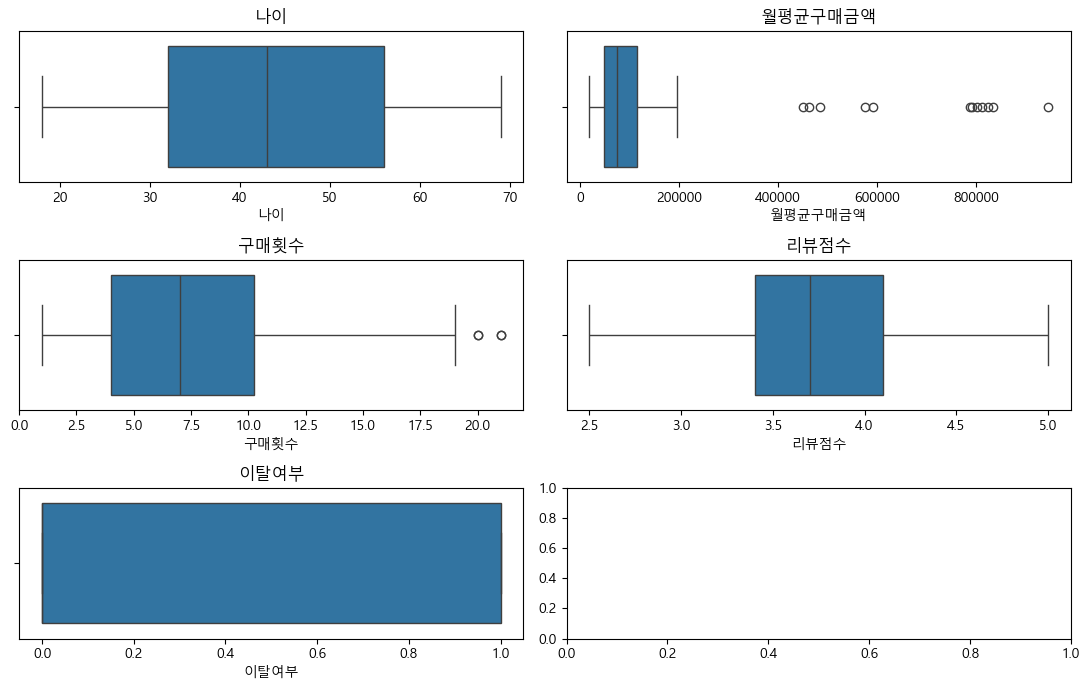

In [222]:
outlier_cols = ["나이", "월평균구매금액", "구매횟수", "리뷰점수", '이탈여부']

fig, axes = plt.subplots(3, 2, figsize=(11, 7))
for col, ax in zip(outlier_cols, axes.flat):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()

- "월평균구매금액" 변수의 박스 플롯으로 이상치 시각화하기

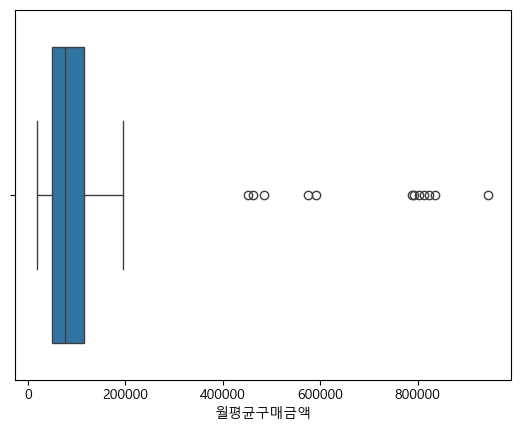

In [223]:
sns.boxplot(x=df['월평균구매금액'])
plt.show()

- IQR(사분위수 범위) 기법을 이용하여 이상치의 하한/상한 경계값을 계산

In [224]:
# Q1(1사분위수) 25%
q1 = df['월평균구매금액'].quantile(.25)

# Q3(3사분위수) 75%
q3 = df['월평균구매금액'].quantile(.75)

# IQR 구하기
iqr = q3 -q1

q1, q3, iqr

(np.float64(48362.456334193215),
 np.float64(114551.09835296536),
 np.float64(66188.64201877214))

In [225]:
# 하한 구하기
lower = q1 - (1.5*iqr)

# 상한 구하기
upper = q3 + (1.5*iqr)

lower, upper

(np.float64(-50920.50669396499), np.float64(213834.06138112355))

- 계산된 경계값을 기준으로 이상치를 제거하거나, 경계값으로 대체(capping)하시오. 처리 방식과 그 이유를 주석으로 명시하시오.

In [226]:
# 이상치의 갯수 구하기
n_outlier = ((df['월평균구매금액'] < lower) | (df['월평균구매금액'] > upper)).sum()
n_outlier

np.int64(12)

In [227]:
# 수치형데이터의 박스플롯을 보게 되면 이상치는 '구매횟수'와 '월평균구매금액'에서만 존재한다.
# 두 데이터 모두 충분히 발생할수 있는 이상치 이므로 이상치를 제거하거나, 경계값으로 대체(capping)할 필요가 없다고 판단이 된다.
# 그러나 지금은 배우는 과정이므로 '월평균구매금액' 데이터의 이상치를 경계계값으로 대체하기로 하고 실습한다.
#  
# Capping(캐핑)은 이상치(outlier)를 삭제하지 않고, 일정 기준을 넘는 값을 기준값으로 바꾸는 기법이다.
# '월평균구매금액' 데이터는 표본 수가 적을수록 뒤쪽 EDA(그룹 비교)에서 신뢰도가 떨어지므로 표본을 유지하면서 극단값만 완화하는 capping이 더 적합하다고 판단 함.
# '월평균구매금액'이 높은 사람은 VVIP 고객일수도 있다.

# .clip() -> 값의 범위를 강제로 잘라내는 함수. 범위 밖으로 튀어나온 값을 범위 안으로 눌러 넣는다.
#            값이 lower 보다 작으면  lower로 바꾼다. / 값이 upper보다 크면  upper로 바꾼다.  그 사이에 있으면 그대로 둔다.
df['월평균구매금액'] = df['월평균구매금액'].clip(lower, upper)
df['월평균구매금액']

0       62705.653045
1      180896.754122
2       30567.640969
3       71563.606370
4      107967.380320
           ...      
495    108578.954159
496     40162.047877
497     51493.570059
498    105068.989111
499     70073.592144
Name: 월평균구매금액, Length: 500, dtype: float64

### 3. 범주형 변수 인코딩

- 인코딩 전/후의 데이터프레임 형태(shape)와 컬럼 목록을 비교

In [228]:
# 범주형 컬럼들의 유니크한 값(카테고리 목록) 확인
for col in df.select_dtypes(exclude='number').columns:
    print(f"[{col}] 컬럼의 값 종류:")
    print(df[col].unique())
    print("-" * 30)

[고객ID] 컬럼의 값 종류:
<StringArray>
['C0001', 'C0002', 'C0003', 'C0004', 'C0005', 'C0006', 'C0007', 'C0008',
 'C0009', 'C0010',
 ...
 'C0491', 'C0492', 'C0493', 'C0494', 'C0495', 'C0496', 'C0497', 'C0498',
 'C0499', 'C0500']
Length: 500, dtype: str
------------------------------
[성별] 컬럼의 값 종류:
<StringArray>
['남', '여']
Length: 2, dtype: str
------------------------------
[거주지역] 컬럼의 값 종류:
<StringArray>
['대구', '부산', '기타', '경기', '서울']
Length: 5, dtype: str
------------------------------
[가입경로] 컬럼의 값 종류:
<StringArray>
['앱', '웹', '광고', '지인추천']
Length: 4, dtype: str
------------------------------
[멤버십등급] 컬럼의 값 종류:
<StringArray>
['실버', 'VIP', '브론즈', '골드']
Length: 4, dtype: str
------------------------------
[쿠폰사용여부] 컬럼의 값 종류:
<StringArray>
['N', 'Y']
Length: 2, dtype: str
------------------------------


- 인코딩 전 데이터프레임 정보 저장

In [229]:
shape_before = df.shape
shape_before

(500, 11)

In [230]:
cols_before = df.columns.tolist()
cols_before

['고객ID',
 '나이',
 '성별',
 '거주지역',
 '가입경로',
 '멤버십등급',
 '월평균구매금액',
 '구매횟수',
 '리뷰점수',
 '쿠폰사용여부',
 '이탈여부']

In [231]:
# LabelEncoder 대신 순서를 직접 지정해 매핑하는 방식을 사용
membership_mapping = {'브론즈': 0, '실버': 1, '골드': 2, 'VIP': 3}
df['멤버십등급'] = df['멤버십등급'].map(membership_mapping)
df

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,이탈여부
0,C0001,22.0,남,대구,앱,1,62705.653045,7.0,3.3,N,1
1,C0002,58.0,여,부산,웹,3,180896.754122,18.0,4.7,Y,0
2,C0003,52.0,여,기타,앱,0,30567.640969,3.0,3.3,Y,0
3,C0004,40.0,여,경기,앱,1,71563.606370,3.0,3.8,N,0
4,C0005,40.0,남,경기,웹,2,107967.380320,7.0,4.9,N,0
...,...,...,...,...,...,...,...,...,...,...,...
495,C0496,39.0,여,경기,웹,2,108578.954159,9.0,3.5,N,0
496,C0497,24.0,여,대구,광고,0,40162.047877,6.0,3.6,N,1
497,C0498,37.0,남,서울,웹,0,51493.570059,3.0,4.1,Y,0
498,C0499,66.0,여,기타,앱,2,105068.989111,6.0,4.4,N,0


In [232]:
ohe_cols = ['성별', '거주지역', '가입경로', '쿠폰사용여부']

# pd.get_dummies 적용 (drop_first=False 기본값 사용, 필요 시 True로 변경 가능)
df = pd.get_dummies(df, columns=ohe_cols, dtype=bool)
df

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,성별_남,성별_여,거주지역_경기,거주지역_기타,거주지역_대구,거주지역_부산,거주지역_서울,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y
0,C0001,22.0,1,62705.653045,7.0,3.3,1,True,False,False,False,True,False,False,False,True,False,False,True,False
1,C0002,58.0,3,180896.754122,18.0,4.7,0,False,True,False,False,False,True,False,False,False,True,False,False,True
2,C0003,52.0,0,30567.640969,3.0,3.3,0,False,True,False,True,False,False,False,False,True,False,False,False,True
3,C0004,40.0,1,71563.606370,3.0,3.8,0,False,True,True,False,False,False,False,False,True,False,False,True,False
4,C0005,40.0,2,107967.380320,7.0,4.9,0,True,False,True,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,C0496,39.0,2,108578.954159,9.0,3.5,0,False,True,True,False,False,False,False,False,False,True,False,True,False
496,C0497,24.0,0,40162.047877,6.0,3.6,1,False,True,False,False,True,False,False,True,False,False,False,True,False
497,C0498,37.0,0,51493.570059,3.0,4.1,0,True,False,False,False,False,False,True,False,False,True,False,False,True
498,C0499,66.0,2,105068.989111,6.0,4.4,0,False,True,False,True,False,False,False,False,True,False,False,True,False


- 레이블 인코딩 (순서가 있는 변수: 멤버십등급)

- 원-핫 인코딩 (순서가 없는 변수: 성별, 거주지역, 가입경로, 쿠폰사용여부)

- 인코딩 후 데이터프레임 정보 저장

In [233]:
shape_after = df.shape
shape_after

(500, 20)

In [234]:
cols_after = df.columns.tolist()
cols_after

['고객ID',
 '나이',
 '멤버십등급',
 '월평균구매금액',
 '구매횟수',
 '리뷰점수',
 '이탈여부',
 '성별_남',
 '성별_여',
 '거주지역_경기',
 '거주지역_기타',
 '거주지역_대구',
 '거주지역_부산',
 '거주지역_서울',
 '가입경로_광고',
 '가입경로_앱',
 '가입경로_웹',
 '가입경로_지인추천',
 '쿠폰사용여부_N',
 '쿠폰사용여부_Y']

- 인코딩 전/후 비교 출력

In [235]:
print("=" * 60)
print("[인코딩 전/후 형태(Shape) 비교]")
print(f"  - 인코딩 전 Shape: {shape_before}  (행: {shape_before[0]}, 열: {shape_before[1]})")
print(f"  - 인코딩 후 Shape: {shape_after}  (행: {shape_after[0]}, 열: {shape_after[1]})")
print("=" * 60)

print("\n[인코딩 전 컬럼 목록]")
print(cols_before)

print("\n[인코딩 후 컬럼 목록]")
print(cols_after)
print("=" * 60)

[인코딩 전/후 형태(Shape) 비교]
  - 인코딩 전 Shape: (500, 11)  (행: 500, 열: 11)
  - 인코딩 후 Shape: (500, 20)  (행: 500, 열: 20)

[인코딩 전 컬럼 목록]
['고객ID', '나이', '성별', '거주지역', '가입경로', '멤버십등급', '월평균구매금액', '구매횟수', '리뷰점수', '쿠폰사용여부', '이탈여부']

[인코딩 후 컬럼 목록]
['고객ID', '나이', '멤버십등급', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부', '성별_남', '성별_여', '거주지역_경기', '거주지역_기타', '거주지역_대구', '거주지역_부산', '거주지역_서울', '가입경로_광고', '가입경로_앱', '가입경로_웹', '가입경로_지인추천', '쿠폰사용여부_N', '쿠폰사용여부_Y']


### < 범주형 변수 인코딩 선택 근거 >

1. 레이블 인코딩 (Label Encoding) 적용 변수
   - `멤버십등급`: '브론즈(0) < 실버(1) < 골드(2) < VIP(3)' 형태로 등급 간 명확한 순서(위계)가 존재한다. 
   - 모델이 등급의 크기 관계를 학습할 수 있도록 레이블 인코딩(직접 매핑)을 적용한다.

2. 원-핫 인코딩 (One-Hot Encoding) 적용 변수
   - `성별`, '거주지역`, `가입경로`, `쿠폰사용여부`: 각 범주 간에 순서나 우열 관계가 존재하지 않는 단순 명목형 변수이다. 
   - 레이블 인코딩을 적용할 경우 숫자의 크기로 인한 부적절한 관계가 학습될 수 있으므로, 각 범주를 독립된 이진(0/1) 컬럼으로 변환하는 원-핫 인코딩을 적용한다.

3. 인코딩 제외 변수
   - `고객ID`: 개별 고객을 식별하기 위한 고유 키(ID) 정보로, 순서나 범주적 의미가 없어 인코딩 대상에서 제외한다.

### 4. 파생변수 생성 및 스케일링

### 파생변수 생성 및 스케일링 선택 근거

1. 파생변수 생성 근거
   - `건당평균구매금액` (`월평균구매금액` / `구매횟수`): 단순한 월 총 구매 금액이나 구매 횟수 외에도, 고객이 1회 구매 시 평균적으로 얼마를 지출하는지(객단가) 파악하는 것이 고객 행동 분석에 매우 유용하다. 
   (단, 구매횟수가 0인 경우 0으로 처리하여 나누기 에러 방지)
   - `연령대` (`나이` 컬럼의 구간화): continuous한 나이 데이터를 20대, 30대, 40대 등의 10년 단위 범주로 구간화(Binning)하여 연령별 특징을 직관적으로 파악할 수 있도록 만든다.

2. 스케일러 선택 근거 (StandardScaler)
   - StandardScaler 적용: 수치형 변수들의 단위(원, 회, 점 등)와 스케일 차이가 크기 때문에, 평균을 0, 표준편차를 1로 맞추는 표준화를 진행한다. 
   - 이상치(Outlier)에 비교적 덜 민감하고, 향후 머신러닝 모델(선형 회귀, 로지스틱 회귀, SVM 등) 학습 시 특성 간의 영향을 균등하게 맞춰주는 데 효과적이다.

- 파생변수 생성

In [236]:
# 파생변수 1 : 건당평균구매금액 (월평균구매금액 / 구매횟수)
# 구매횟수가 0인 경우 발생할 수 있는 inf/NaN 방지를 위해 np.where 활용
df["건당평균구매금액"] = np.where(df["구매횟수"] > 0, df["월평균구매금액"] / df["구매횟수"], 0)

# 파생변수 2 : 연령대 (10년 단위 구간화)
# 나이를 10으로 나눈 몫에 10을 곱하여 10, 20, 30...으로 대체
df["연령대"] = (df["나이"] // 10 * 10).astype(int)
df.head()

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,성별_남,성별_여,거주지역_경기,...,거주지역_부산,거주지역_서울,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y,건당평균구매금액,연령대
0,C0001,22.0,1,62705.653045,7.0,3.3,1,True,False,False,...,False,False,False,True,False,False,True,False,8957.950435,20
1,C0002,58.0,3,180896.754122,18.0,4.7,0,False,True,False,...,True,False,False,False,True,False,False,True,10049.819673,50
2,C0003,52.0,0,30567.640969,3.0,3.3,0,False,True,False,...,False,False,False,True,False,False,False,True,10189.213656,50
3,C0004,40.0,1,71563.606370,3.0,3.8,0,False,True,True,...,False,False,False,True,False,False,True,False,23854.535457,40
4,C0005,40.0,2,107967.380320,7.0,4.9,0,True,False,True,...,False,False,False,False,True,False,True,False,15423.911474,40


- 스케일링 적용 (StandardScaler)

In [237]:
# 스케일링 대상 수치형 컬럼 선정 (고객ID, ID 형태의 변수 및 인코딩된 범주형 변수 제외)
# 원본 수치형 변수 + 새로 생성한 수치형 파생변수 포함
num_cols = ["나이", "월평균구매금액", "구매횟수", "리뷰점수", "건당평균구매금액"]

# 스케일링 전 기술통계량 저장
desc_before = df[num_cols].describe()
desc_before

,나이,월평균구매금액,구매횟수,리뷰점수,건당평균구매금액
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43.180000,86092.413399,7.822000,3.734800,13129.800389
std,14.384764,47003.366902,4.481795,0.540382,8858.181124
min,18.000000,19127.903927,1.000000,2.500000,2732.557704
25%,32.000000,48362.456334,4.000000,3.400000,8792.086134
50%,43.000000,74770.324856,7.000000,3.700000,10854.226803
75%,56.000000,114551.098353,10.250000,4.100000,13857.202365
max,69.000000,213834.061381,21.000000,5.000000,71278.020460


In [238]:
# StandardScaler 객체 생성 및 적용
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# 스케일링 후 기술통계량 저장
desc_after = df[num_cols].describe()
desc_after

,나이,월평균구매금액,구매횟수,리뷰점수,건당평균구매금액
count,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02
mean,1.776357e-18,7.815970e-17,-2.842171e-17,-6.359357e-16,1.127987e-16
std,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00
min,-1.752216e+00,-1.426102e+00,-1.523682e+00,-2.287338e+00,-1.174920e+00
25%,-7.779896e-01,-8.035115e-01,-8.536373e-01,-6.201819e-01,-4.901749e-01
50%,-1.252577e-02,-2.411195e-01,-1.835923e-01,-6.446335e-02,-2.571468e-01
75%,8.921133e-01,6.060669e-01,5.422898e-01,6.764947e-01,8.219864e-02
max,1.796752e+00,2.720435e+00,2.943284e+00,2.343650e+00,6.570926e+00


- 스케일링 전/후 기술통계량 비교 출력

In [239]:
print("=" * 70)
print(" [스케일링 적용 전 기술통계량 (describe)]")
print(desc_before.round(2))
print("=" * 70)

print("\n [스케일링 적용 후 기술통계량 (describe) - 평균 0, 표준편차 1 확인]")
print(desc_after.round(2))
print("=" * 70)

 [스케일링 적용 전 기술통계량 (describe)]
           나이    월평균구매금액    구매횟수    리뷰점수  건당평균구매금액
count  500.00     500.00  500.00  500.00    500.00
mean    43.18   86092.41    7.82    3.73  13129.80
std     14.38   47003.37    4.48    0.54   8858.18
min     18.00   19127.90    1.00    2.50   2732.56
25%     32.00   48362.46    4.00    3.40   8792.09
50%     43.00   74770.32    7.00    3.70  10854.23
75%     56.00  114551.10   10.25    4.10  13857.20
max     69.00  213834.06   21.00    5.00  71278.02

 [스케일링 적용 후 기술통계량 (describe) - 평균 0, 표준편차 1 확인]
           나이  월평균구매금액    구매횟수    리뷰점수  건당평균구매금액
count  500.00   500.00  500.00  500.00    500.00
mean     0.00     0.00   -0.00   -0.00      0.00
std      1.00     1.00    1.00    1.00      1.00
min     -1.75    -1.43   -1.52   -2.29     -1.17
25%     -0.78    -0.80   -0.85   -0.62     -0.49
50%     -0.01    -0.24   -0.18   -0.06     -0.26
75%      0.89     0.61    0.54    0.68      0.08
max      1.80     2.72    2.94    2.34      6.57


- 최종 전처리 완료 데이터 저장

In [241]:
file_name = "prj_data_cleaned.csv"
df.to_csv(file_name, index=False, encoding="utf-8-sig")

print(f"\n 최종 전처리 데이터가 '{file_name}' 파일로 성공적으로 저장되었습니다!")
print(f" - 최종 데이터 Shape: {df.shape}")


 최종 전처리 데이터가 'prj_data_cleaned.csv' 파일로 성공적으로 저장되었습니다!
 - 최종 데이터 Shape: (500, 22)
